# Fit graphical model on training set

Loads the train pickle, builds the flat dataframe, runs `models.graphical_model.fit`,
saves `ModelParams` to `models/fitted_params.pkl`, and visualizes both the
background and EV components.

In [26]:
import sys
from pathlib import Path

repo_root = str(Path('.').resolve().parents[1])
utils_dir = str(Path('.').resolve().parents[1] / 'notebooks' / 'utils')
for path in [repo_root, utils_dir]:
    if path not in sys.path:
        sys.path.insert(0, path)

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models import graphical_model as gm
import background_plots as bgp
import ev_plots as evp

## Load and preprocess train_df

In [ ]:
raw_train = pickle.load(open('../../data_processing/splits/train.pkl', 'rb'))

train_df = pd.concat(
    [df.assign(home_id=home_id, has_ev=has_ev, city=city)
     for home_id, (has_ev, city, df) in raw_train.items()]
).reset_index()
train_df.rename(columns={'car1': 'ev_load', 'load': 'total_load'}, inplace=True)
train_df['day'] = train_df['localminute'].dt.normalize()
train_df['time'] = train_df['localminute'].dt.strftime('%H:%M')
train_df = train_df.drop(columns='localminute')
train_df['time'] = pd.to_timedelta(train_df['time'] + ':00')
train_df['time_index'] = (train_df['time'].dt.total_seconds() // (15 * 60)).astype(int)
train_df['charge_state'] = train_df['charge_state'].astype('int')

full_day_mask = (
    train_df.groupby(['home_id', 'day'])['time_index']
    .transform(lambda x: x.nunique() == 96)
)
train_df = train_df[full_day_mask]
print(f'rows={len(train_df):,}  homes={train_df.home_id.nunique()}')

## Fit

In [ ]:
params = gm.fit(train_df, verbose=True)

## Save fitted parameters

In [ ]:
out_path = Path('../../models/fitted_params.pkl')
with open(out_path, 'wb') as f:
    pickle.dump(params, f)
print(f'Saved to {out_path.resolve()}')

## Parameter sanity-check (ρ, σ^NonEV, P_z)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(params.rho, lw=1.5)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title(r'Background profile $\rho_t$')
axes[0].set_xlabel('15-min interval (0=midnight)')
axes[0].set_ylabel(r'$\rho_t$ (unit norm)')

axes[1].plot(np.sqrt(params.sigma2_nonev), lw=1.5)
axes[1].set_title(r'Per-time noise $\sigma^{\mathrm{NonEV}}_t$')
axes[1].set_xlabel('15-min interval')
axes[1].set_ylabel('kW')

im = axes[2].imshow(params.P_z, cmap='Blues', vmin=0, vmax=1)
axes[2].set_xticks(range(3)); axes[2].set_xticklabels(['off', 'low', 'high'])
axes[2].set_yticks(range(3)); axes[2].set_yticklabels(['off', 'low', 'high'])
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, f'{params.P_z[i,j]:.3f}', ha='center', va='center',
                     color='white' if params.P_z[i,j] > 0.5 else 'black')
axes[2].set_title(r'$P_z$ (rows: from, cols: to)')
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.show()

---
## Background load: empirical vs model

Two figures:
1. **Stacked time-series** — one row per home + one row for the prior predictive.
   All rows share the same absolute kW y-axis.
2. **Alpha forest plot** — per-home posterior α ± 1σ vs global prior.

In [25]:
# ── CONFIGURE ──────────────────────────────────────────────────────────────
bg_homes_to_plot = [27, 661, 203, 387, 1450]   # None = all homes; or e.g. [27, 661, 203, 387, 1450]

show_individual_traces = True   # faint individual daily traces
show_empirical_band    = True   # empirical mean ± 1 std band
show_alpha_band        = True   # band from alpha posterior uncertainty alone
show_combined_band     = True   # band from alpha uncertainty + sigma^NonEV

max_trace_days = 50
# ───────────────────────────────────────────────────────────────────────────

all_home_ids = sorted(train_df['home_id'].unique())
bg_plot_ids  = bg_homes_to_plot if bg_homes_to_plot is not None else all_home_ids
print(f'Plotting {len(bg_plot_ids)} homes')

Plotting 5 homes


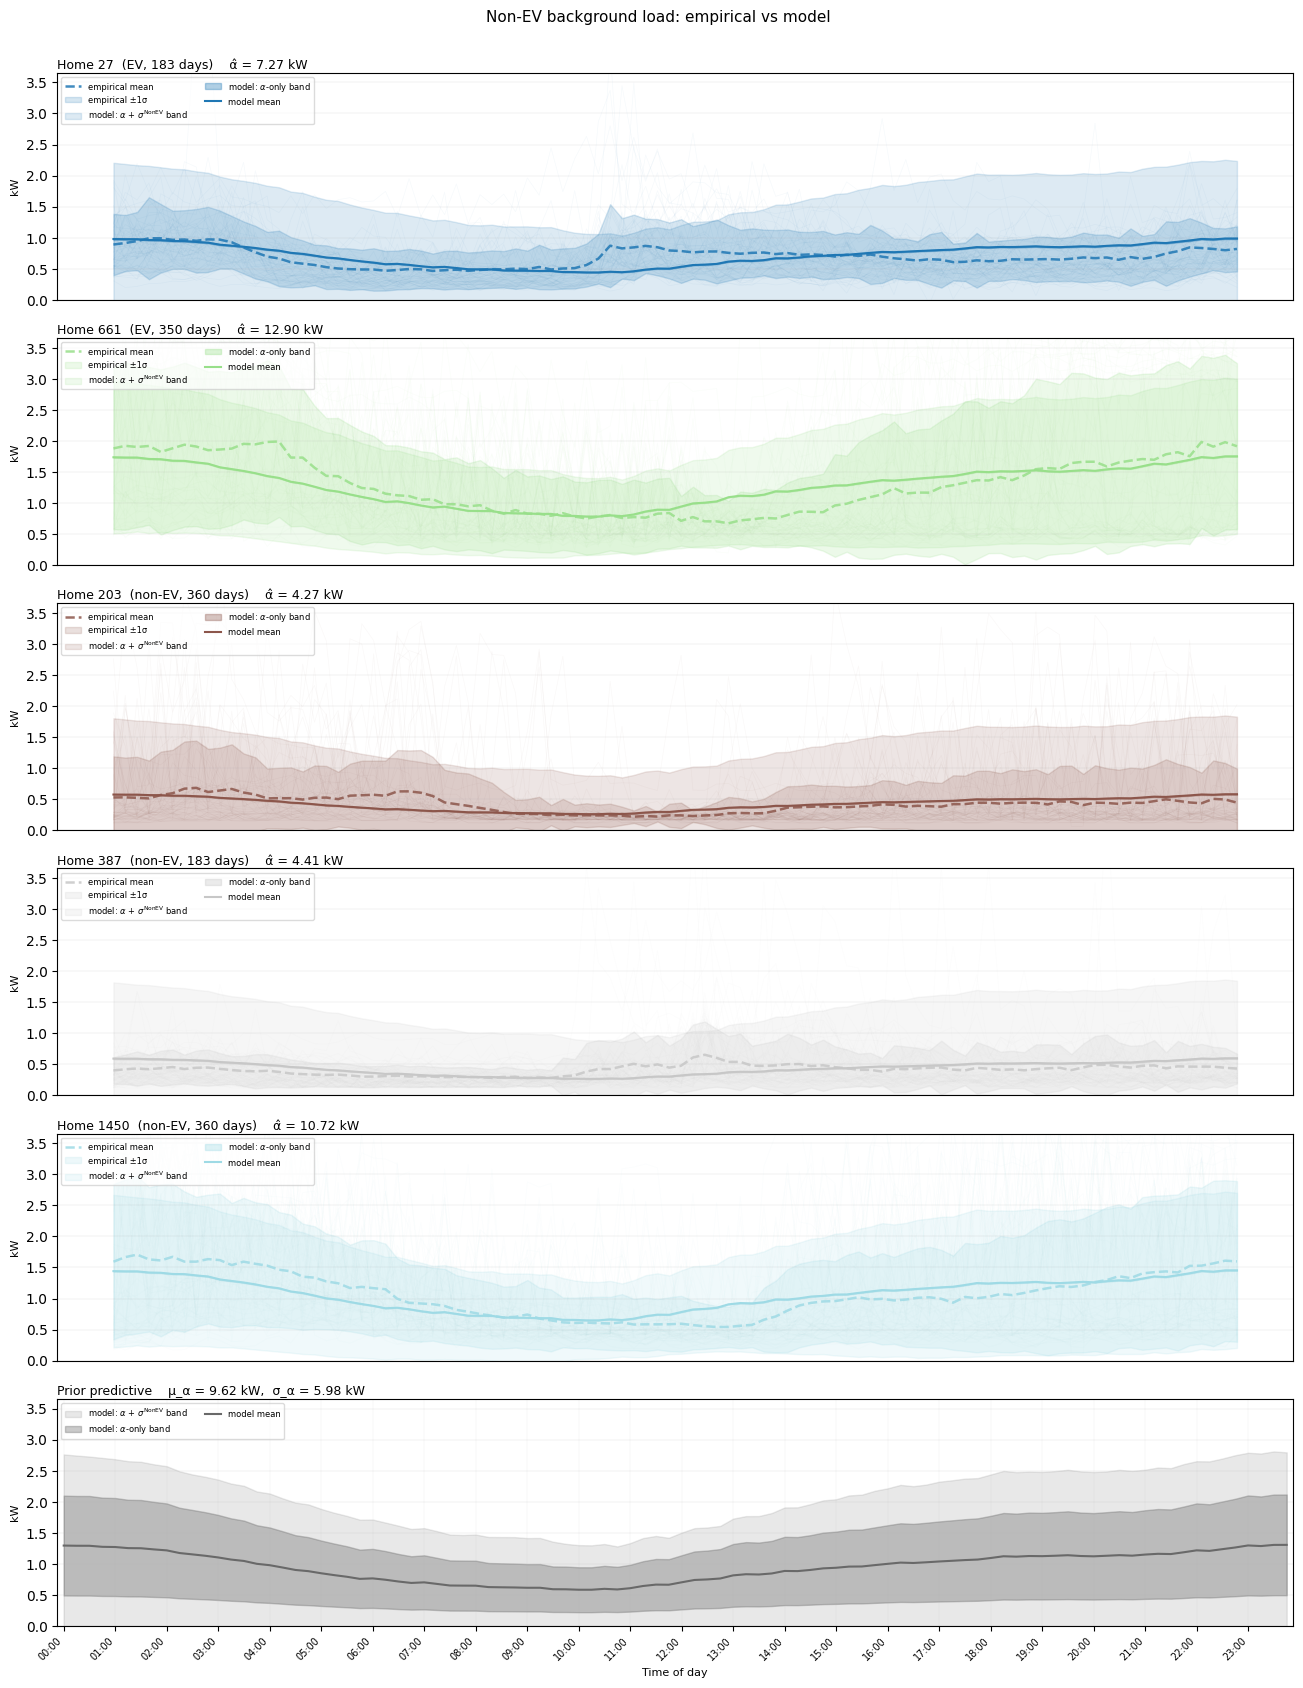

In [27]:
fig_bg_timeseries = bgp.plot_background_comparison(
    train_df               = train_df,
    params                 = params,
    home_ids               = bg_plot_ids,
    show_individual_traces = show_individual_traces,
    show_empirical_band    = show_empirical_band,
    show_alpha_band        = show_alpha_band,
    show_combined_band     = show_combined_band,
    max_trace_days         = max_trace_days,
)
plt.show()

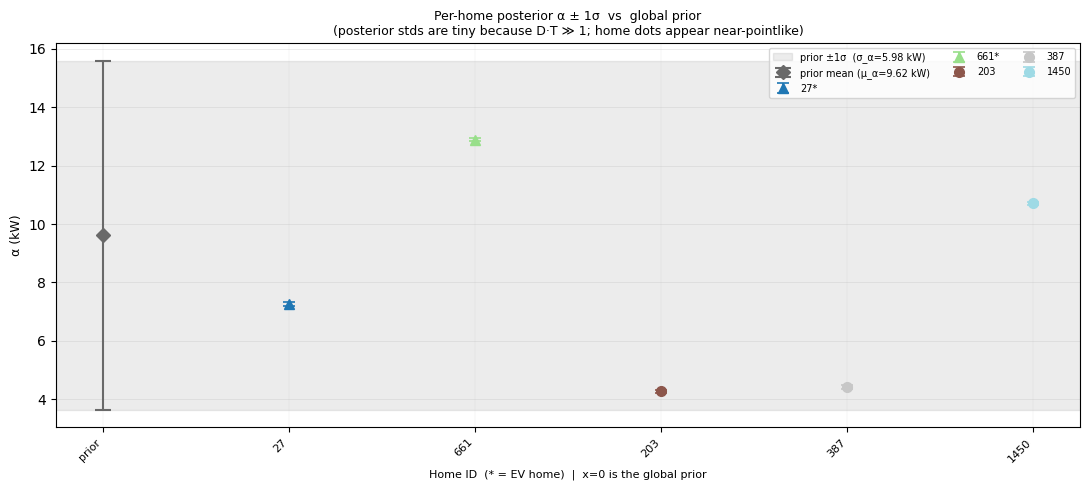

In [28]:
fig_bg_forest = bgp.plot_alpha_posteriors(
    train_df = train_df,
    params   = params,
    home_ids = bg_plot_ids,
)
plt.show()

---
## EV charging magnitudes: empirical vs model

Two figures (EV homes only for the per-home plot; all homes for the forest plot):
1. **Stacked per-state plots** — one row per EV home.
   x-axis = {off, low, high}; y-axis = EV load in kW, shared absolute scale.
2. **Theta forest plot** — per-home posterior Θ_k ± 1σ vs global prior at x=0.
   Three state values stacked vertically per home, connected by a thin line.

In [43]:
# ── CONFIGURE ──────────────────────────────────────────────────────────────
ev_homes_to_plot = [27, 661, 203, 387, 1450]   # None = all homes; or e.g. [27, 661, 4767]
                          # non-EV homes are silently skipped in the per-home plot
                          # but included (faded) in the forest plot

show_individual_points = False   # jittered scatter of raw ev_load obs (downsampled)
show_empirical_band    = True   # empirical mean ± 1 std error bar
show_theta_only_band   = False   # posterior Θ ± posterior std
show_combined_band     = True   # posterior Θ ± sqrt(posterior_std² + sigma_EV²)

max_scatter_points = 300   # max raw observations per state per home
# ───────────────────────────────────────────────────────────────────────────

ev_plot_ids = ev_homes_to_plot if ev_homes_to_plot is not None else all_home_ids
print(f'Using {len(ev_plot_ids)} home IDs')

Using 5 home IDs


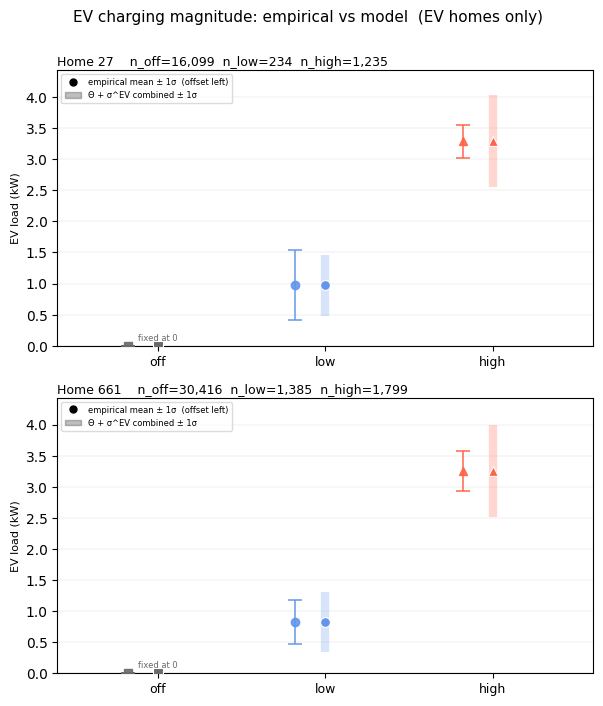

In [44]:
fig_ev_per_home = evp.plot_ev_magnitude_comparison(
    train_df               = train_df,
    params                 = params,
    home_ids               = ev_plot_ids,
    show_individual_points = show_individual_points,
    show_empirical_band    = show_empirical_band,
    show_theta_only_band   = show_theta_only_band,
    show_combined_band     = show_combined_band,
    max_scatter_points     = max_scatter_points,
)
plt.show()

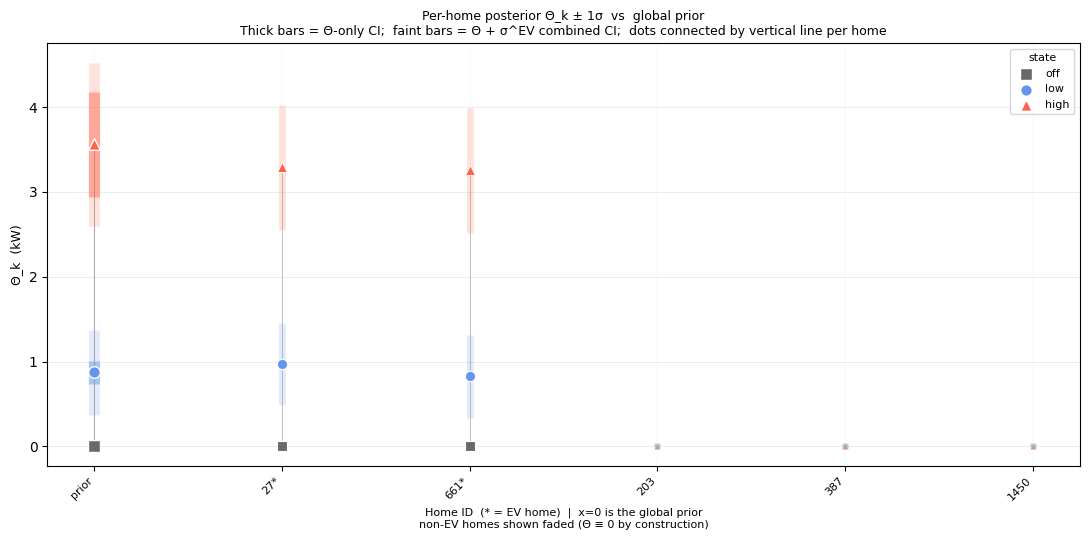

In [31]:
fig_ev_forest = evp.plot_theta_posteriors(
    train_df = train_df,
    params   = params,
    home_ids = ev_plot_ids,
)
plt.show()